In [ ]:
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')

path = '/content/drive/MyDrive/capstone/'

folder = 'results/llama-8b/'

def metrics(data, vmwe_or_compound):
  if 'compound' in vmwe_or_compound:
    data0 = data[data['output'] == 'No compound found.']
    data1 = data[data['output'] != 'No compound found.']

    data00 = data0[data0['label'] == 'No compound found.']
    data01 = data0[data0['label'] != 'No compound found.']

    data10 = data1[data1['label'] == 'No compound found.']
    data11 = data1[data1['label'] != 'No compound found.']
  else:
    data0 = data[data['output'] == 'No MWE found.']
    data1 = data[data['output'] != 'No MWE found.']

    data00 = data0[data0['label'] == 'No MWE found.']
    data01 = data0[data0['label'] != 'No MWE found.']

    data10 = data1[data1['label'] == 'No MWE found.']
    data11 = data1[data1['label'] != 'No MWE found.']

  return data00, data01, data10, data11, len(data00), len(data01), len(data10), len(data11), len(data)

def separate(labels):
  labels = labels.split('\n')
  labels_separated = {'label': [], 'span': []}
  for i in labels:
    a = i.split(': ', 1)
    labels_separated['label'].append(a[0])
    labels_separated['span'].append(a[1])
  return labels_separated



def exact_match(data):
    return len(data[data['output']==data['label']])/len(data)

def exact_match_by_line(pred_labels, gold_labels, care_label = False, penalty = 0.25):
    pred = separate(pred_labels)
    gold = separate(gold_labels)

    matched = 0
    total_gold = len(gold['spans'])
    total_pred = len(pred['spans'])
    matches = []

    for i in range(len(gold['span'])):
        match = -1
        label_match = 0
        for j in range(len(pred['span'])):
            if gold['span'][i] == pred['span'][j]:
                match = j
                if gold['label'][i] == pred['label'][j]:
                    label_match = 1
                    break

        if match != -1:
            matches.append([(gold['label'][i], gold['span'][i]), (pred['label'][match], pred['span'][match])])
            if care_label == False:
                matched += 1
            else:
                if label_match == 1:
                    matched += 1
                else:
                    matched += (1 - penalty)
            del pred['span'][match]
            del pred['label'][match]
        del gold['span'][i]
        del gold['label'][i]
        i = i-1

    precision = matched/total_pred
    recall = matched/total_gold


    f1 = 2*(precision*recall)/(precision+recall)

    return match_item(matches, precision, recall, f1, matched, total_pred, total_gold)

def match_by_line_total(preds, golds, algorithm = exact_match_by_line, care_label = False, penalty = 0.25):
    #preds and golds should have the same number of instances
    total_gold = 0
    total_pred = 0
    matched = 0
    matches = []

    for i in range(len(preds)):
        a = algorithm(preds[i], golds[i], care_label, penalty)
        total_gold += a.total_gold
        total_pred += a.total_pred
        matched += a.matched
        matches = matches + a.matches
    precision = matched/total_pred
    recall = matched/total_gold
    f1 = 2*(precision*recall)/(precision+recall)
    return match_item(matches, precision, recall, f1, matched, total_pred, total_gold)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


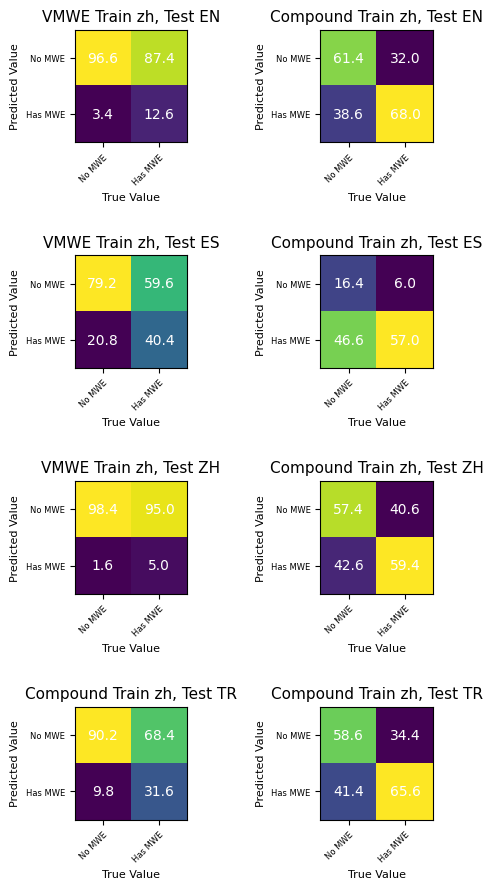

([[67.8, 34.4], [32.2, 65.6]], 0.22639792610134157, ['en', 'EN'])
([[72.8, 46.8], [27.2, 53.2]], 0.0, ['en', 'ES'])
([[97.4, 90.4], [2.6, 9.6]], 0.0, ['en', 'ZH'])
([[83.2, 66.0], [16.8, 34.0]], 0.0, ['en', 'TR'])

([[87.2, 61.4], [12.8, 38.6]], 0.0, ['es', 'EN'])
([[65.2, 34.8], [34.8, 65.2]], 0.022279990880725725, ['es', 'ES'])
([[99.6, 98.8], [0.4, 1.2]], 0.0, ['es', 'ZH'])
([[87.4, 60.2], [12.6, 39.8]], 0.0, ['es', 'TR'])

([[96.6, 87.4], [3.4, 12.6]], 0.0, ['zh', 'EN'])
([[79.2, 59.6], [20.8, 40.4]], 0.0, ['zh', 'ES'])
([[98.4, 95.0], [1.6, 5.0]], 0.08333333333333333, ['zh', 'ZH'])
([[90.2, 68.4], [9.8, 31.6]], 0.0, ['zh', 'TR'])

([[90.2, 70.2], [9.8, 29.8]], 0.07766917293233083, ['tr', 'EN'])
([[79.2, 48.2], [20.8, 51.8]], 0.0, ['tr', 'ES'])
([[100.0, 99.8], [0.0, 0.2]], 0.0, ['tr', 'ZH'])
([[85.2, 54.2], [14.8, 45.8]], 0.1474434976787918, ['tr', 'TR'])


In [ ]:
def get_base_metrics(seed_start, seed_end, lang_train, lang_test, model_name, path = path+folder):
  count_00 = 0
  count_01 = 0
  count_10 = 0
  count_11 = 0

  exact_match_accuracy = 0
  exact_match_count = 0
  #total = 0
  for i in range(seed_start,seed_end):
    a = pd.read_csv(path + model_name + '_train_' + lang_train + '_test_' + lang_test + '_' + str(i) + '.csv')
    b = metrics(a, model_name)
    count_00 += b[4]
    count_01 += b[5]
    count_10 += b[6]
    count_11 += b[7]
    #total += b[8]
    if len(b[3])!=0:
      exact_match_accuracy += exact_match(b[3])
      exact_match_count += 1

  if exact_match_count == 0:
    e = -1
  else:
    e = exact_match_accuracy/(exact_match_count)

  return [[count_00/(seed_end - seed_start), count_01/(seed_end - seed_start)], [count_10/(seed_end - seed_start), count_11/(seed_end - seed_start)]], e, [lang_train, lang_test]

import matplotlib.pyplot as plt
import numpy as np


def make_confusion_matrix(result, language_pairs):
  #adapted from https://matplotlib.org/stable/gallery/images_contours_and_fields/image_annotated_heatmap.html
  #6 items in results
  a = np.array(result[0])
  fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6),(ax7,ax8)) = plt.subplots(4,2, figsize = (6,10))
  plt.subplots_adjust(wspace = 0.05, hspace = 1, left = 0.1, top = 0.9)
  im1 = ax1.imshow(result[0])
  ax1.set_xticks(range(2),labels = ['No MWE','Has MWE'], ha = 'right', rotation_mode = 'anchor', rotation = 45, fontsize = 6)
  ax1.set_yticks(range(2),labels = ['No MWE','Has MWE'], fontsize = 6)
  ax1.set_xlabel('True Value', fontsize = 8)
  ax1.set_ylabel('Predicted Value', fontsize = 8)
  ax1.set_title('VMWE Train ' + language_pairs[0][0] + ', Test ' + language_pairs[0][1], fontsize = 11)
  for i in range(2):
    for j in range(2):
      text = ax1.text(j, i, result[0][i][j], ha = 'center', va='center',color='w')
  im2 = ax2.imshow(result[1])
  ax2.set_xticks(range(2), labels = ['No MWE','Has MWE'], ha = 'right', rotation_mode = 'anchor', rotation = 45, fontsize = 6)
  ax2.set_yticks(range(2), labels = ['No MWE','Has MWE'], fontsize = 6)
  ax2.set_xlabel('True Value', fontsize = 8)
  ax2.set_ylabel('Predicted Value', fontsize = 8)
  ax2.set_title('Compound Train ' + language_pairs[1][0] + ', Test ' + language_pairs[1][1], fontsize = 11)
  for i in range(2):
    for j in range(2):
      text = ax2.text(j, i, result[1][i][j], ha = 'center', va='center',color='w')
  im3 = ax3.imshow(result[2])
  ax3.set_xticks(range(2), labels = ['No MWE','Has MWE'], ha = 'right', rotation_mode = 'anchor', rotation = 45, fontsize = 6)
  ax3.set_yticks(range(2), labels = ['No MWE','Has MWE'], fontsize = 6)
  ax3.set_xlabel('True Value', fontsize = 8)
  ax3.set_ylabel('Predicted Value', fontsize = 8)
  ax3.set_title('VMWE Train ' + language_pairs[2][0] + ', Test ' + language_pairs[2][1], fontsize = 11)
  for i in range(2):
    for j in range(2):
      text = ax3.text(j, i, result[2][i][j], ha = 'center', va='center',color='w')
  im4 = ax4.imshow(result[3])
  ax4.set_xticks(range(2), labels = ['No MWE','Has MWE'], ha = 'right', rotation_mode = 'anchor', rotation = 45, fontsize = 6)
  ax4.set_yticks(range(2), labels = ['No MWE','Has MWE'], fontsize = 6)
  ax4.set_xlabel('True Value', fontsize = 8)
  ax4.set_ylabel('Predicted Value', fontsize = 8)
  ax4.set_title('Compound Train ' + language_pairs[3][0] + ', Test ' + language_pairs[3][1], fontsize = 11)
  for i in range(2):
    for j in range(2):
      text = ax4.text(j, i, result[3][i][j], ha = 'center', va='center',color='w')
  im5 = ax5.imshow(result[4])
  ax5.set_xticks(range(2), labels = ['No MWE','Has MWE'], ha = 'right', rotation_mode = 'anchor', rotation = 45, fontsize = 6)
  ax5.set_yticks(range(2), labels = ['No MWE','Has MWE'], fontsize = 6)
  ax5.set_xlabel('True Value', fontsize = 8)
  ax5.set_ylabel('Predicted Value', fontsize = 8)
  ax5.set_title('VMWE Train ' + language_pairs[4][0] + ', Test ' + language_pairs[4][1], fontsize = 11)
  for i in range(2):
    for j in range(2):
      text = ax5.text(j, i, result[4][i][j], ha = 'center', va='center',color='w')
  im6 = ax6.imshow(result[5])
  ax6.set_xticks(range(2), labels = ['No MWE','Has MWE'], ha = 'right', rotation_mode = 'anchor', rotation = 45, fontsize = 6)
  ax6.set_yticks(range(2), labels = ['No MWE','Has MWE'], fontsize = 6)
  ax6.set_xlabel('True Value', fontsize = 8)
  ax6.set_ylabel('Predicted Value', fontsize = 8)
  ax6.set_title('Compound Train ' + language_pairs[5][0] + ', Test ' + language_pairs[5][1], fontsize = 11)
  for i in range(2):
    for j in range(2):
      text = ax6.text(j, i, result[5][i][j], ha = 'center', va='center',color='w')
  im7 = ax7.imshow(result[6])
  ax7.set_xticks(range(2), labels = ['No MWE','Has MWE'], ha = 'right', rotation_mode = 'anchor', rotation = 45, fontsize = 6)
  ax7.set_yticks(range(2), labels = ['No MWE','Has MWE'], fontsize = 6)
  ax7.set_xlabel('True Value', fontsize = 8)
  ax7.set_ylabel('Predicted Value', fontsize = 8)
  ax7.set_title('Compound Train ' + language_pairs[6][0] + ', Test ' + language_pairs[6][1], fontsize = 11)
  for i in range(2):
    for j in range(2):
      text = ax7.text(j, i, result[6][i][j], ha = 'center', va='center',color='w')
  im8 = ax8.imshow(result[7])
  ax8.set_xticks(range(2), labels = ['No MWE','Has MWE'], ha = 'right', rotation_mode = 'anchor', rotation = 45, fontsize = 6)
  ax8.set_yticks(range(2), labels = ['No MWE','Has MWE'], fontsize = 6)
  ax8.set_xlabel('True Value', fontsize = 8)
  ax8.set_ylabel('Predicted Value', fontsize = 8)
  ax8.set_title('Compound Train ' + language_pairs[7][0] + ', Test ' + language_pairs[7][1], fontsize = 11)
  for i in range(2):
    for j in range(2):
      text = ax8.text(j, i, result[7][i][j], ha = 'center', va='center',color='w')
  plt.show()


a = get_base_metrics(0,5,'zh','EN','vmwe_0shot')
b = get_base_metrics(0,5,'zh','EN','compound_0shot')
c = get_base_metrics(0,5,'zh','ES','vmwe_0shot')
d = get_base_metrics(0,5,'zh','ES','compound_0shot')
e = get_base_metrics(0,5,'zh','ZH','vmwe_0shot')
f = get_base_metrics(0,5,'zh','ZH','compound_0shot')
g = get_base_metrics(0,5,'zh','TR','vmwe_0shot')
h = get_base_metrics(0,5,'zh','TR','compound_0shot')

make_confusion_matrix([a[0],b[0],c[0],d[0],e[0],f[0],g[0],h[0]],[a[2],b[2],c[2],d[2],e[2],f[2],g[2],h[2]])
"""
print(get_base_metrics(0,5,'en','EN','vmwe_fewshot'))
#print(get_base_metrics(0,5,'en','EN','compound_fewshot'))
print(get_base_metrics(0,5,'en','ES','vmwe_fewshot'))
#print(get_base_metrics(0,5,'en','ES','compound_fewshot'))
print(get_base_metrics(0,5,'en','ZH','vmwe_fewshot'))
#print(get_base_metrics(0,5,'en','ZH','compound_fewshot'))
print(get_base_metrics(0,5,'en','TR','vmwe_fewshot'))
#print(get_base_metrics(0,5,'en','TR','compound_fewshot'))
print()
print(get_base_metrics(0,5,'es','EN','vmwe_fewshot'))
#print(get_base_metrics(0,5,'es','EN','compound_fewshot'))
print(get_base_metrics(0,5,'es','ES','vmwe_fewshot'))
#print(get_base_metrics(0,5,'es','ES','compound_fewshot'))
print(get_base_metrics(0,5,'es','ZH','vmwe_fewshot'))
#print(get_base_metrics(0,5,'es','ZH','compound_fewshot'))
print(get_base_metrics(0,5,'es','TR','vmwe_fewshot'))
#print(get_base_metrics(0,5,'es','TR','compound_fewshot'))
print()
print(get_base_metrics(0,5,'zh','EN','vmwe_fewshot'))
#print(get_base_metrics(0,5,'zh','EN','compound_fewshot'))
print(get_base_metrics(0,5,'zh','ES','vmwe_fewshot'))
#print(get_base_metrics(0,5,'zh','ES','compound_fewshot'))
print(get_base_metrics(0,5,'zh','ZH','vmwe_fewshot'))
#print(get_base_metrics(0,5,'zh','ZH','compound_fewshot'))
print(get_base_metrics(0,5,'zh','TR','vmwe_fewshot'))
#print(get_base_metrics(0,5,'zh','TR','compound_fewshot'))
print()
print(get_base_metrics(0,5,'tr','EN','vmwe_fewshot'))
#print(get_base_metrics(0,5,'tr','EN','compound_fewshot'))
print(get_base_metrics(0,5,'tr','ES','vmwe_fewshot'))
#print(get_base_metrics(0,5,'tr','ES','compound_fewshot'))
print(get_base_metrics(0,5,'tr','ZH','vmwe_fewshot'))
#print(get_base_metrics(0,5,'tr','ZH','compound_fewshot'))
print(get_base_metrics(0,5,'tr','TR','vmwe_fewshot'))
#print(get_base_metrics(0,5,'tr','TR','compound_fewshot'))

#print(get_base_metrics(0,5,'en','EN','vmwe_fewshot'))
print(get_base_metrics(0,5,'en','EN','compound_fewshot'))
#print(get_base_metrics(0,5,'en','ES','vmwe_fewshot'))
print(get_base_metrics(0,5,'en','ES','compound_fewshot'))
#print(get_base_metrics(0,5,'en','ZH','vmwe_fewshot'))
print(get_base_metrics(0,5,'en','ZH','compound_fewshot'))
#print(get_base_metrics(0,5,'en','TR','vmwe_fewshot'))
print(get_base_metrics(0,5,'en','TR','compound_fewshot'))
print()
#print(get_base_metrics(0,5,'es','EN','vmwe_fewshot'))
print(get_base_metrics(0,5,'es','EN','compound_fewshot'))
#print(get_base_metrics(0,5,'es','ES','vmwe_fewshot'))
print(get_base_metrics(0,5,'es','ES','compound_fewshot'))
#print(get_base_metrics(0,5,'es','ZH','vmwe_fewshot'))
print(get_base_metrics(0,5,'es','ZH','compound_fewshot'))
#print(get_base_metrics(0,5,'es','TR','vmwe_fewshot'))
print(get_base_metrics(0,5,'es','TR','compound_fewshot'))
print()
#print(get_base_metrics(0,5,'zh','EN','vmwe_fewshot'))
print(get_base_metrics(0,5,'zh','EN','compound_fewshot'))
#print(get_base_metrics(0,5,'zh','ES','vmwe_fewshot'))
print(get_base_metrics(0,5,'zh','ES','compound_fewshot'))
#print(get_base_metrics(0,5,'zh','ZH','vmwe_fewshot'))
print(get_base_metrics(0,5,'zh','ZH','compound_fewshot'))
#print(get_base_metrics(0,5,'zh','TR','vmwe_fewshot'))
print(get_base_metrics(0,5,'zh','TR','compound_fewshot'))
print()
#print(get_base_metrics(0,5,'tr','EN','vmwe_fewshot'))
print(get_base_metrics(0,5,'tr','EN','compound_fewshot'))
#print(get_base_metrics(0,5,'tr','ES','vmwe_fewshot'))
print(get_base_metrics(0,5,'tr','ES','compound_fewshot'))
#print(get_base_metrics(0,5,'tr','ZH','vmwe_fewshot'))
print(get_base_metrics(0,5,'tr','ZH','compound_fewshot'))
#print(get_base_metrics(0,5,'tr','TR','vmwe_fewshot'))
print(get_base_metrics(0,5,'tr','TR','compound_fewshot'))



#print(get_base_metrics(0,5,'en','EN','vmwe_0shot'))
print(get_base_metrics(0,5,'en','EN','compound_0shot'))
#print(get_base_metrics(0,5,'en','ES','vmwe_0shot'))
print(get_base_metrics(0,5,'en','ES','compound_0shot'))
#print(get_base_metrics(0,5,'en','ZH','vmwe_0shot'))
print(get_base_metrics(0,5,'en','ZH','compound_0shot'))
#print(get_base_metrics(0,5,'en','TR','vmwe_0shot'))
print(get_base_metrics(0,5,'en','TR','compound_0shot'))
print()
#print(get_base_metrics(0,5,'es','EN','vmwe_0shot'))
print(get_base_metrics(0,5,'es','EN','compound_0shot'))
#print(get_base_metrics(0,5,'es','ES','vmwe_0shot'))
print(get_base_metrics(0,5,'es','ES','compound_0shot'))
#print(get_base_metrics(0,5,'es','ZH','vmwe_0shot'))
print(get_base_metrics(0,5,'es','ZH','compound_0shot'))
#print(get_base_metrics(0,5,'es','TR','vmwe_0shot'))
print(get_base_metrics(0,5,'es','TR','compound_0shot'))
print()
#print(get_base_metrics(0,5,'zh','EN','vmwe_0shot'))
print(get_base_metrics(0,5,'zh','EN','compound_0shot'))
#print(get_base_metrics(0,5,'zh','ES','vmwe_0shot'))
print(get_base_metrics(0,5,'zh','ES','compound_0shot'))
#print(get_base_metrics(0,5,'zh','ZH','vmwe_0shot'))
print(get_base_metrics(0,5,'zh','ZH','compound_0shot'))
#print(get_base_metrics(0,5,'zh','TR','vmwe_0shot'))
print(get_base_metrics(0,5,'zh','TR','compound_0shot'))
print()
#print(get_base_metrics(0,5,'tr','EN','vmwe_0shot'))
print(get_base_metrics(0,5,'tr','EN','compound_0shot'))
#print(get_base_metrics(0,5,'tr','ES','vmwe_0shot'))
print(get_base_metrics(0,5,'tr','ES','compound_0shot'))
#print(get_base_metrics(0,5,'tr','ZH','vmwe_0shot'))
print(get_base_metrics(0,5,'tr','ZH','compound_0shot'))
#print(get_base_metrics(0,5,'tr','TR','vmwe_0shot'))
print(get_base_metrics(0,5,'tr','TR','compound_0shot'))
"""
print(get_base_metrics(0,5,'en','EN','vmwe_0shot'))
#print(get_base_metrics(0,5,'en','EN','compound_0shot'))
print(get_base_metrics(0,5,'en','ES','vmwe_0shot'))
#print(get_base_metrics(0,5,'en','ES','compound_0shot'))
print(get_base_metrics(0,5,'en','ZH','vmwe_0shot'))
#print(get_base_metrics(0,5,'en','ZH','compound_0shot'))
print(get_base_metrics(0,5,'en','TR','vmwe_0shot'))
#print(get_base_metrics(0,5,'en','TR','compound_0shot'))
print()
print(get_base_metrics(0,5,'es','EN','vmwe_0shot'))
#print(get_base_metrics(0,5,'es','EN','compound_0shot'))
print(get_base_metrics(0,5,'es','ES','vmwe_0shot'))
#print(get_base_metrics(0,5,'es','ES','compound_0shot'))
print(get_base_metrics(0,5,'es','ZH','vmwe_0shot'))
#print(get_base_metrics(0,5,'es','ZH','compound_0shot'))
print(get_base_metrics(0,5,'es','TR','vmwe_0shot'))
#print(get_base_metrics(0,5,'es','TR','compound_0shot'))
print()
print(get_base_metrics(0,5,'zh','EN','vmwe_0shot'))
#print(get_base_metrics(0,5,'zh','EN','compound_0shot'))
print(get_base_metrics(0,5,'zh','ES','vmwe_0shot'))
#print(get_base_metrics(0,5,'zh','ES','compound_0shot'))
print(get_base_metrics(0,5,'zh','ZH','vmwe_0shot'))
#print(get_base_metrics(0,5,'zh','ZH','compound_0shot'))
print(get_base_metrics(0,5,'zh','TR','vmwe_0shot'))
#print(get_base_metrics(0,5,'zh','TR','compound_0shot'))
print()
print(get_base_metrics(0,5,'tr','EN','vmwe_0shot'))
#print(get_base_metrics(0,5,'tr','EN','compound_0shot'))
print(get_base_metrics(0,5,'tr','ES','vmwe_0shot'))
#print(get_base_metrics(0,5,'tr','ES','compound_0shot'))
print(get_base_metrics(0,5,'tr','ZH','vmwe_0shot'))
#print(get_base_metrics(0,5,'tr','ZH','compound_0shot'))
print(get_base_metrics(0,5,'tr','TR','vmwe_0shot'))
#print(get_base_metrics(0,5,'tr','TR','compound_0shot'))



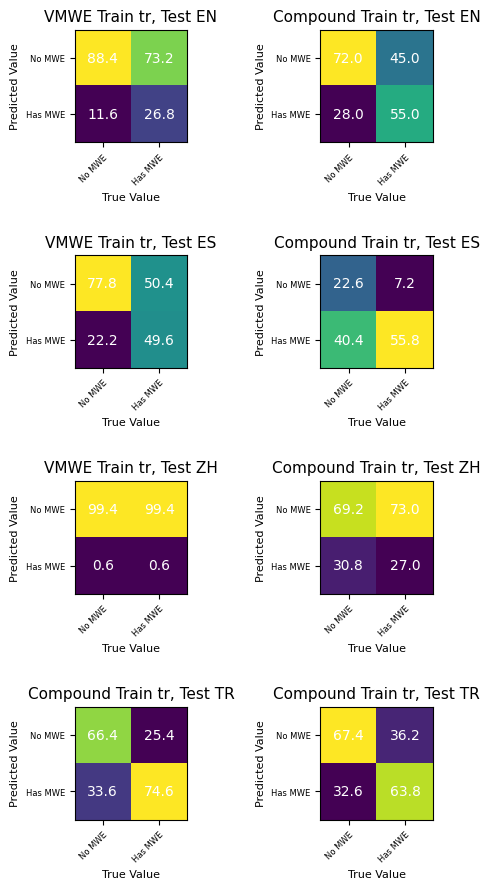

([[88.2, 62.6], [11.8, 37.4]], 0.4045924908424909, ['en', 'EN'])
([[81.2, 54.2], [18.8, 45.8]], 0.0, ['en', 'ES'])
([[99.6, 100.0], [0.4, 0.0]], -1, ['en', 'ZH'])
([[99.6, 98.6], [0.4, 1.4]], 0.0, ['en', 'TR'])

([[99.6, 95.8], [0.4, 4.2]], 0.0, ['es', 'EN'])
([[86.8, 70.4], [13.2, 29.6]], 0.15895767390504234, ['es', 'ES'])
([[100.0, 99.8], [0.0, 0.2]], 0.0, ['es', 'ZH'])
([[98.6, 94.2], [1.4, 5.8]], 0.0, ['es', 'TR'])

([[97.0, 86.8], [3.0, 13.2]], 0.061050420168067235, ['zh', 'EN'])
([[90.2, 84.8], [9.8, 15.2]], 0.0, ['zh', 'ES'])
([[79.0, 36.8], [21.0, 63.2]], 0.22096856022448952, ['zh', 'ZH'])
([[100.0, 93.2], [0.0, 6.8]], 0.0, ['zh', 'TR'])

([[99.0, 97.8], [1.0, 2.2]], 0.0, ['tr', 'EN'])
([[98.4, 97.4], [1.6, 2.6]], 0.041666666666666664, ['tr', 'ES'])
([[99.8, 100.0], [0.2, 0.0]], -1, ['tr', 'ZH'])
([[91.2, 65.0], [8.8, 35.0]], 0.09871794871794873, ['tr', 'TR'])


"\n#print(get_base_metrics(0,5,'en','EN','vmwe_fewshot'))\nprint(get_base_metrics(0,5,'en','EN','compound_fewshot'))\n#print(get_base_metrics(0,5,'en','ES','vmwe_fewshot'))\nprint(get_base_metrics(0,5,'en','ES','compound_fewshot'))\n#print(get_base_metrics(0,5,'en','ZH','vmwe_fewshot'))\nprint(get_base_metrics(0,5,'en','ZH','compound_fewshot'))\n#print(get_base_metrics(0,5,'en','TR','vmwe_fewshot'))\nprint(get_base_metrics(0,5,'en','TR','compound_fewshot'))\nprint()\n#print(get_base_metrics(0,5,'es','EN','vmwe_fewshot'))\nprint(get_base_metrics(0,5,'es','EN','compound_fewshot'))\n#print(get_base_metrics(0,5,'es','ES','vmwe_fewshot'))\nprint(get_base_metrics(0,5,'es','ES','compound_fewshot'))\n#print(get_base_metrics(0,5,'es','ZH','vmwe_fewshot'))\nprint(get_base_metrics(0,5,'es','ZH','compound_fewshot'))\n#print(get_base_metrics(0,5,'es','TR','vmwe_fewshot'))\nprint(get_base_metrics(0,5,'es','TR','compound_fewshot'))\nprint()\n#print(get_base_metrics(0,5,'zh','EN','vmwe_fewshot'))\npri

In [ ]:
path = '/content/drive/MyDrive/capstone/'

folder = 'results/qwen-32b/'

def get_base_metrics(seed_start, seed_end, lang_train, lang_test, model_name, path = path+folder):
  count_00 = 0
  count_01 = 0
  count_10 = 0
  count_11 = 0

  exact_match_accuracy = 0
  exact_match_count = 0
  #total = 0
  for i in range(seed_start,seed_end):
    a = pd.read_csv(path + model_name + '_train_' + lang_train + '_test_' + lang_test + '_' + str(i) + '.csv')
    b = metrics(a, model_name)
    count_00 += b[4]
    count_01 += b[5]
    count_10 += b[6]
    count_11 += b[7]
    #total += b[8]
    if len(b[3])!=0:
      exact_match_accuracy += exact_match(b[3])
      exact_match_count += 1

  if exact_match_count == 0:
    e = -1
  else:
    e = exact_match_accuracy/(exact_match_count)

  return [[count_00/(seed_end - seed_start), count_01/(seed_end - seed_start)], [count_10/(seed_end - seed_start), count_11/(seed_end - seed_start)]], e, [lang_train, lang_test]

import matplotlib.pyplot as plt
import numpy as np


def make_confusion_matrix(result, language_pairs):
  #adapted from https://matplotlib.org/stable/gallery/images_contours_and_fields/image_annotated_heatmap.html
  #6 items in results
  a = np.array(result[0])
  fig, ((ax1, ax2), (ax3, ax4), (ax5, ax6),(ax7,ax8)) = plt.subplots(4,2, figsize = (6,10))
  plt.subplots_adjust(wspace = 0.05, hspace = 1, left = 0.1, top = 0.9)
  im1 = ax1.imshow(result[0])
  ax1.set_xticks(range(2),labels = ['No MWE','Has MWE'], ha = 'right', rotation_mode = 'anchor', rotation = 45, fontsize = 6)
  ax1.set_yticks(range(2),labels = ['No MWE','Has MWE'], fontsize = 6)
  ax1.set_xlabel('True Value', fontsize = 8)
  ax1.set_ylabel('Predicted Value', fontsize = 8)
  ax1.set_title('VMWE Train ' + language_pairs[0][0] + ', Test ' + language_pairs[0][1], fontsize = 11)
  for i in range(2):
    for j in range(2):
      text = ax1.text(j, i, result[0][i][j], ha = 'center', va='center',color='w')
  im2 = ax2.imshow(result[1])
  ax2.set_xticks(range(2), labels = ['No MWE','Has MWE'], ha = 'right', rotation_mode = 'anchor', rotation = 45, fontsize = 6)
  ax2.set_yticks(range(2), labels = ['No MWE','Has MWE'], fontsize = 6)
  ax2.set_xlabel('True Value', fontsize = 8)
  ax2.set_ylabel('Predicted Value', fontsize = 8)
  ax2.set_title('Compound Train ' + language_pairs[1][0] + ', Test ' + language_pairs[1][1], fontsize = 11)
  for i in range(2):
    for j in range(2):
      text = ax2.text(j, i, result[1][i][j], ha = 'center', va='center',color='w')
  im3 = ax3.imshow(result[2])
  ax3.set_xticks(range(2), labels = ['No MWE','Has MWE'], ha = 'right', rotation_mode = 'anchor', rotation = 45, fontsize = 6)
  ax3.set_yticks(range(2), labels = ['No MWE','Has MWE'], fontsize = 6)
  ax3.set_xlabel('True Value', fontsize = 8)
  ax3.set_ylabel('Predicted Value', fontsize = 8)
  ax3.set_title('VMWE Train ' + language_pairs[2][0] + ', Test ' + language_pairs[2][1], fontsize = 11)
  for i in range(2):
    for j in range(2):
      text = ax3.text(j, i, result[2][i][j], ha = 'center', va='center',color='w')
  im4 = ax4.imshow(result[3])
  ax4.set_xticks(range(2), labels = ['No MWE','Has MWE'], ha = 'right', rotation_mode = 'anchor', rotation = 45, fontsize = 6)
  ax4.set_yticks(range(2), labels = ['No MWE','Has MWE'], fontsize = 6)
  ax4.set_xlabel('True Value', fontsize = 8)
  ax4.set_ylabel('Predicted Value', fontsize = 8)
  ax4.set_title('Compound Train ' + language_pairs[3][0] + ', Test ' + language_pairs[3][1], fontsize = 11)
  for i in range(2):
    for j in range(2):
      text = ax4.text(j, i, result[3][i][j], ha = 'center', va='center',color='w')
  im5 = ax5.imshow(result[4])
  ax5.set_xticks(range(2), labels = ['No MWE','Has MWE'], ha = 'right', rotation_mode = 'anchor', rotation = 45, fontsize = 6)
  ax5.set_yticks(range(2), labels = ['No MWE','Has MWE'], fontsize = 6)
  ax5.set_xlabel('True Value', fontsize = 8)
  ax5.set_ylabel('Predicted Value', fontsize = 8)
  ax5.set_title('VMWE Train ' + language_pairs[4][0] + ', Test ' + language_pairs[4][1], fontsize = 11)
  for i in range(2):
    for j in range(2):
      text = ax5.text(j, i, result[4][i][j], ha = 'center', va='center',color='w')
  im6 = ax6.imshow(result[5])
  ax6.set_xticks(range(2), labels = ['No MWE','Has MWE'], ha = 'right', rotation_mode = 'anchor', rotation = 45, fontsize = 6)
  ax6.set_yticks(range(2), labels = ['No MWE','Has MWE'], fontsize = 6)
  ax6.set_xlabel('True Value', fontsize = 8)
  ax6.set_ylabel('Predicted Value', fontsize = 8)
  ax6.set_title('Compound Train ' + language_pairs[5][0] + ', Test ' + language_pairs[5][1], fontsize = 11)
  for i in range(2):
    for j in range(2):
      text = ax6.text(j, i, result[5][i][j], ha = 'center', va='center',color='w')
  im7 = ax7.imshow(result[6])
  ax7.set_xticks(range(2), labels = ['No MWE','Has MWE'], ha = 'right', rotation_mode = 'anchor', rotation = 45, fontsize = 6)
  ax7.set_yticks(range(2), labels = ['No MWE','Has MWE'], fontsize = 6)
  ax7.set_xlabel('True Value', fontsize = 8)
  ax7.set_ylabel('Predicted Value', fontsize = 8)
  ax7.set_title('Compound Train ' + language_pairs[6][0] + ', Test ' + language_pairs[6][1], fontsize = 11)
  for i in range(2):
    for j in range(2):
      text = ax7.text(j, i, result[6][i][j], ha = 'center', va='center',color='w')
  im8 = ax8.imshow(result[7])
  ax8.set_xticks(range(2), labels = ['No MWE','Has MWE'], ha = 'right', rotation_mode = 'anchor', rotation = 45, fontsize = 6)
  ax8.set_yticks(range(2), labels = ['No MWE','Has MWE'], fontsize = 6)
  ax8.set_xlabel('True Value', fontsize = 8)
  ax8.set_ylabel('Predicted Value', fontsize = 8)
  ax8.set_title('Compound Train ' + language_pairs[7][0] + ', Test ' + language_pairs[7][1], fontsize = 11)
  for i in range(2):
    for j in range(2):
      text = ax8.text(j, i, result[7][i][j], ha = 'center', va='center',color='w')
  plt.show()


a = get_base_metrics(0,5,'tr','EN','vmwe_0shot')
b = get_base_metrics(0,5,'tr','EN','compound_0shot')
c = get_base_metrics(0,5,'tr','ES','vmwe_0shot')
d = get_base_metrics(0,5,'tr','ES','compound_0shot')
e = get_base_metrics(0,5,'tr','ZH','vmwe_0shot')
f = get_base_metrics(0,5,'tr','ZH','compound_0shot')
g = get_base_metrics(0,5,'tr','TR','vmwe_0shot')
h = get_base_metrics(0,5,'tr','TR','compound_0shot')

make_confusion_matrix([a[0],b[0],c[0],d[0],e[0],f[0],g[0],h[0]],[a[2],b[2],c[2],d[2],e[2],f[2],g[2],h[2]])

print(get_base_metrics(0,5,'en','EN','vmwe_fewshot'))
#print(get_base_metrics(0,5,'en','EN','compound_fewshot'))
print(get_base_metrics(0,5,'en','ES','vmwe_fewshot'))
#print(get_base_metrics(0,5,'en','ES','compound_fewshot'))
print(get_base_metrics(0,5,'en','ZH','vmwe_fewshot'))
#print(get_base_metrics(0,5,'en','ZH','compound_fewshot'))
print(get_base_metrics(0,5,'en','TR','vmwe_fewshot'))
#print(get_base_metrics(0,5,'en','TR','compound_fewshot'))
print()
print(get_base_metrics(0,5,'es','EN','vmwe_fewshot'))
#print(get_base_metrics(0,5,'es','EN','compound_fewshot'))
print(get_base_metrics(0,5,'es','ES','vmwe_fewshot'))
#print(get_base_metrics(0,5,'es','ES','compound_fewshot'))
print(get_base_metrics(0,5,'es','ZH','vmwe_fewshot'))
#print(get_base_metrics(0,5,'es','ZH','compound_fewshot'))
print(get_base_metrics(0,5,'es','TR','vmwe_fewshot'))
#print(get_base_metrics(0,5,'es','TR','compound_fewshot'))
print()
print(get_base_metrics(0,5,'zh','EN','vmwe_fewshot'))
#print(get_base_metrics(0,5,'zh','EN','compound_fewshot'))
print(get_base_metrics(0,5,'zh','ES','vmwe_fewshot'))
#print(get_base_metrics(0,5,'zh','ES','compound_fewshot'))
print(get_base_metrics(0,5,'zh','ZH','vmwe_fewshot'))
#print(get_base_metrics(0,5,'zh','ZH','compound_fewshot'))
print(get_base_metrics(0,5,'zh','TR','vmwe_fewshot'))
#print(get_base_metrics(0,5,'zh','TR','compound_fewshot'))
print()
print(get_base_metrics(0,5,'tr','EN','vmwe_fewshot'))
#print(get_base_metrics(0,5,'tr','EN','compound_fewshot'))
print(get_base_metrics(0,5,'tr','ES','vmwe_fewshot'))
#print(get_base_metrics(0,5,'tr','ES','compound_fewshot'))
print(get_base_metrics(0,5,'tr','ZH','vmwe_fewshot'))
#print(get_base_metrics(0,5,'tr','ZH','compound_fewshot'))
print(get_base_metrics(0,5,'tr','TR','vmwe_fewshot'))
#print(get_base_metrics(0,5,'tr','TR','compound_fewshot'))
"""
#print(get_base_metrics(0,5,'en','EN','vmwe_fewshot'))
print(get_base_metrics(0,5,'en','EN','compound_fewshot'))
#print(get_base_metrics(0,5,'en','ES','vmwe_fewshot'))
print(get_base_metrics(0,5,'en','ES','compound_fewshot'))
#print(get_base_metrics(0,5,'en','ZH','vmwe_fewshot'))
print(get_base_metrics(0,5,'en','ZH','compound_fewshot'))
#print(get_base_metrics(0,5,'en','TR','vmwe_fewshot'))
print(get_base_metrics(0,5,'en','TR','compound_fewshot'))
print()
#print(get_base_metrics(0,5,'es','EN','vmwe_fewshot'))
print(get_base_metrics(0,5,'es','EN','compound_fewshot'))
#print(get_base_metrics(0,5,'es','ES','vmwe_fewshot'))
print(get_base_metrics(0,5,'es','ES','compound_fewshot'))
#print(get_base_metrics(0,5,'es','ZH','vmwe_fewshot'))
print(get_base_metrics(0,5,'es','ZH','compound_fewshot'))
#print(get_base_metrics(0,5,'es','TR','vmwe_fewshot'))
print(get_base_metrics(0,5,'es','TR','compound_fewshot'))
print()
#print(get_base_metrics(0,5,'zh','EN','vmwe_fewshot'))
print(get_base_metrics(0,5,'zh','EN','compound_fewshot'))
#print(get_base_metrics(0,5,'zh','ES','vmwe_fewshot'))
print(get_base_metrics(0,5,'zh','ES','compound_fewshot'))
#print(get_base_metrics(0,5,'zh','ZH','vmwe_fewshot'))
print(get_base_metrics(0,5,'zh','ZH','compound_fewshot'))
#print(get_base_metrics(0,5,'zh','TR','vmwe_fewshot'))
print(get_base_metrics(0,5,'zh','TR','compound_fewshot'))
print()
#print(get_base_metrics(0,5,'tr','EN','vmwe_fewshot'))
print(get_base_metrics(0,5,'tr','EN','compound_fewshot'))
#print(get_base_metrics(0,5,'tr','ES','vmwe_fewshot'))
print(get_base_metrics(0,5,'tr','ES','compound_fewshot'))
#print(get_base_metrics(0,5,'tr','ZH','vmwe_fewshot'))
print(get_base_metrics(0,5,'tr','ZH','compound_fewshot'))
#print(get_base_metrics(0,5,'tr','TR','vmwe_fewshot'))
print(get_base_metrics(0,5,'tr','TR','compound_fewshot'))



#print(get_base_metrics(0,5,'en','EN','vmwe_0shot'))
print(get_base_metrics(0,5,'en','EN','compound_0shot'))
#print(get_base_metrics(0,5,'en','ES','vmwe_0shot'))
print(get_base_metrics(0,5,'en','ES','compound_0shot'))
#print(get_base_metrics(0,5,'en','ZH','vmwe_0shot'))
print(get_base_metrics(0,5,'en','ZH','compound_0shot'))
#print(get_base_metrics(0,5,'en','TR','vmwe_0shot'))
print(get_base_metrics(0,5,'en','TR','compound_0shot'))
print()
#print(get_base_metrics(0,5,'es','EN','vmwe_0shot'))
print(get_base_metrics(0,5,'es','EN','compound_0shot'))
#print(get_base_metrics(0,5,'es','ES','vmwe_0shot'))
print(get_base_metrics(0,5,'es','ES','compound_0shot'))
#print(get_base_metrics(0,5,'es','ZH','vmwe_0shot'))
print(get_base_metrics(0,5,'es','ZH','compound_0shot'))
#print(get_base_metrics(0,5,'es','TR','vmwe_0shot'))
print(get_base_metrics(0,5,'es','TR','compound_0shot'))
print()
#print(get_base_metrics(0,5,'zh','EN','vmwe_0shot'))
print(get_base_metrics(0,5,'zh','EN','compound_0shot'))
#print(get_base_metrics(0,5,'zh','ES','vmwe_0shot'))
print(get_base_metrics(0,5,'zh','ES','compound_0shot'))
#print(get_base_metrics(0,5,'zh','ZH','vmwe_0shot'))
print(get_base_metrics(0,5,'zh','ZH','compound_0shot'))
#print(get_base_metrics(0,5,'zh','TR','vmwe_0shot'))
print(get_base_metrics(0,5,'zh','TR','compound_0shot'))
print()
#print(get_base_metrics(0,5,'tr','EN','vmwe_0shot'))
print(get_base_metrics(0,5,'tr','EN','compound_0shot'))
#print(get_base_metrics(0,5,'tr','ES','vmwe_0shot'))
print(get_base_metrics(0,5,'tr','ES','compound_0shot'))
#print(get_base_metrics(0,5,'tr','ZH','vmwe_0shot'))
print(get_base_metrics(0,5,'tr','ZH','compound_0shot'))
#print(get_base_metrics(0,5,'tr','TR','vmwe_0shot'))
print(get_base_metrics(0,5,'tr','TR','compound_0shot'))

print(get_base_metrics(0,5,'en','EN','vmwe_0shot'))
#print(get_base_metrics(0,5,'en','EN','compound_0shot'))
print(get_base_metrics(0,5,'en','ES','vmwe_0shot'))
#print(get_base_metrics(0,5,'en','ES','compound_0shot'))
print(get_base_metrics(0,5,'en','ZH','vmwe_0shot'))
#print(get_base_metrics(0,5,'en','ZH','compound_0shot'))
print(get_base_metrics(0,5,'en','TR','vmwe_0shot'))
#print(get_base_metrics(0,5,'en','TR','compound_0shot'))
print()
print(get_base_metrics(0,5,'es','EN','vmwe_0shot'))
#print(get_base_metrics(0,5,'es','EN','compound_0shot'))
print(get_base_metrics(0,5,'es','ES','vmwe_0shot'))
#print(get_base_metrics(0,5,'es','ES','compound_0shot'))
print(get_base_metrics(0,5,'es','ZH','vmwe_0shot'))
#print(get_base_metrics(0,5,'es','ZH','compound_0shot'))
print(get_base_metrics(0,5,'es','TR','vmwe_0shot'))
#print(get_base_metrics(0,5,'es','TR','compound_0shot'))
print()
print(get_base_metrics(0,5,'zh','EN','vmwe_0shot'))
#print(get_base_metrics(0,5,'zh','EN','compound_0shot'))
print(get_base_metrics(0,5,'zh','ES','vmwe_0shot'))
#print(get_base_metrics(0,5,'zh','ES','compound_0shot'))
print(get_base_metrics(0,5,'zh','ZH','vmwe_0shot'))
#print(get_base_metrics(0,5,'zh','ZH','compound_0shot'))
print(get_base_metrics(0,5,'zh','TR','vmwe_0shot'))
#print(get_base_metrics(0,5,'zh','TR','compound_0shot'))
print()
print(get_base_metrics(0,5,'tr','EN','vmwe_0shot'))
#print(get_base_metrics(0,5,'tr','EN','compound_0shot'))
print(get_base_metrics(0,5,'tr','ES','vmwe_0shot'))
#print(get_base_metrics(0,5,'tr','ES','compound_0shot'))
print(get_base_metrics(0,5,'tr','ZH','vmwe_0shot'))
#print(get_base_metrics(0,5,'tr','ZH','compound_0shot'))
print(get_base_metrics(0,5,'tr','TR','vmwe_0shot'))
#print(get_base_metrics(0,5,'tr','TR','compound_0shot'))

"""